# U08 | Seq2Seq + Teacher Forcing

**本单元目标**：理解 Seq2Seq 架构，掌握 Teacher Forcing 技巧，完成数字反转任务。

1. 为什么需要 Seq2Seq -- 变长输入变长输出问题
2. Encoder（编码器）原理
3. Decoder（解码器）原理
4. Teacher Forcing：训练加速技巧
5. 特殊 Token：SOS / EOS / PAD
6. 训练 vs 推理流程对比
7. 完整代码：数字反转任务

**过关标准**：数字反转任务准确率 >95%，能解释 Teacher Forcing 的训练/推理差异。

---

## 1. 为什么需要 Seq2Seq

RNN/GRU 的输入输出是 **等长** 的：读入 T 个词，输出 T 个隐藏状态。

但翻译任务是 **不等长** 的：

```
输入：「你  好」        (2个词)
输出：「Hello」         (1个词)

输入：「How are you」   (3个词)
输出：「你  好  吗」    (3个词)

输入：「I love you so much」  (5个词)
输出：「我  爱  你」          (3个词)
```

Seq2Seq（Sequence to Sequence）将问题拆成两步：

```
输入序列  ->  [Encoder]  ->  Context Vector  ->  [Decoder]  ->  输出序列
                              (固定大小)            逐步生成
```

**核心思想**：先「读懂」，再「说出来」。
- Encoder 负责理解整个输入，压缩成一个向量
- Decoder 根据这个向量，一个词一个词地生成输出

## 2. Encoder（编码器）

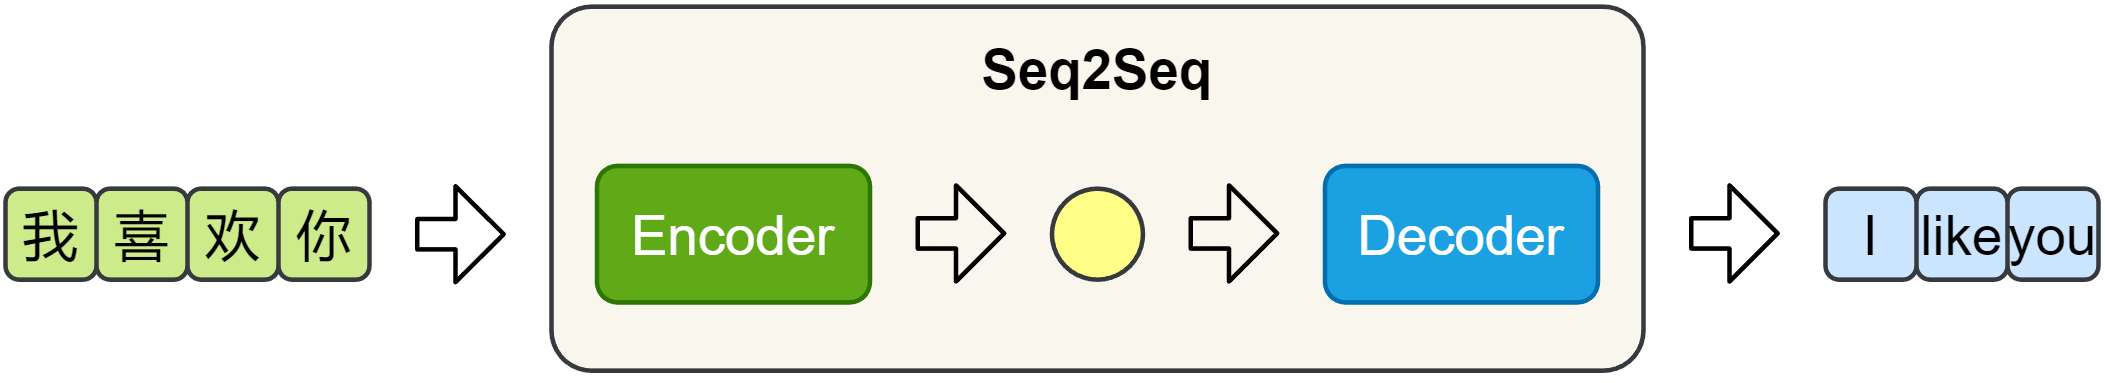

Encoder 就是一个普通的 GRU，**只保留最后时刻的隐藏状态**：

```python
class Encoder(nn.Module):
    def forward(self, x):
        # x: (batch, src_len)
        embedded = self.embedding(x)           # (batch, src_len, embed_dim)
        output, hidden = self.gru(embedded)    # hidden: (1, batch, hidden_dim)
        return hidden                          # 只返回最后时刻
```

**输入输出形状**：

| 张量 | 形状 | 说明 |
|------|------|------|
| `x` | (batch, src_len) | 输入词索引 |
| `embedded` | (batch, src_len, embed_dim) | 词向量 |
| `output` | (batch, src_len, hidden_dim) | 每步隐藏状态，不用 |
| `hidden` | (1, batch, hidden_dim) | **Context Vector，传给 Decoder** |

**Context Vector**：编码器读完整个句子后的「总结」，是 Encoder 和 Decoder 之间唯一的信息传递通道。

```
比喻：你读完一本书（输入序列），然后用一句话总结（context vector），
再根据这句话翻译成另一种语言（输出序列）。
```

> **局限性**：对于很长的句子，强行压缩成一个固定大小向量会丢失细节。
> U11 的 Attention 机制就是为了解决这个问题。

## 3. Decoder（解码器）

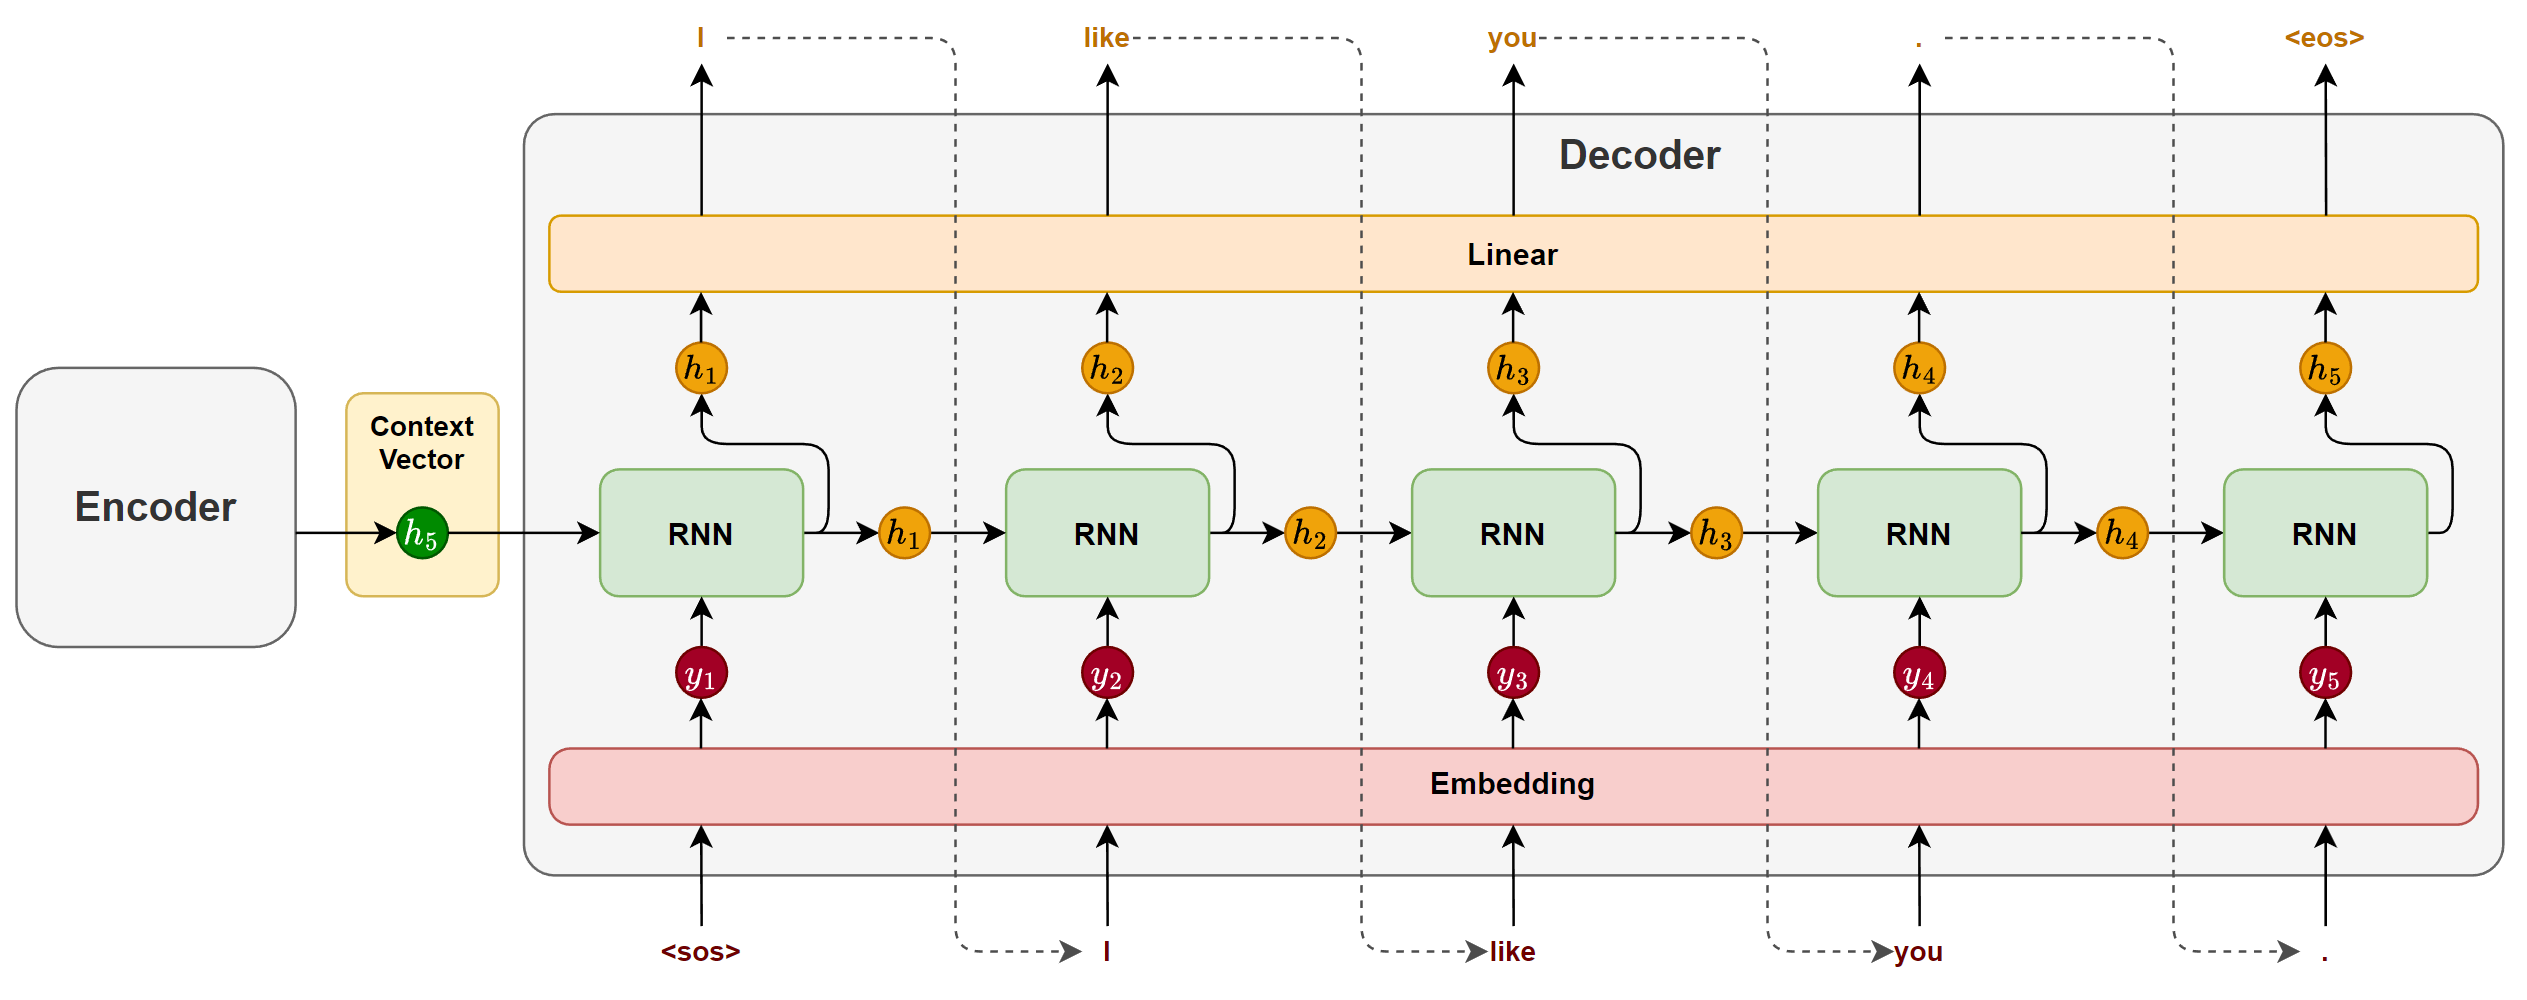

Decoder **每次只处理一个 token**，同时维护自己的 hidden state：

```python
class Decoder(nn.Module):
    def forward(self, x, hidden):
        # x:      (batch, 1)              -- 当前输入的一个 token
        # hidden: (1, batch, hidden_dim)  -- 上一步的隐藏状态（初始=context vector）
        embedded = self.embedding(x)               # (batch, 1, embed_dim)
        output, hidden = self.gru(embedded, hidden) # output: (batch, 1, hidden_dim)
        logits = self.fc(output.squeeze(1))         # (batch, vocab_size)
        return logits, hidden
```

**生成流程**（推理时）：

```
步骤 0：input=SOS,  hidden=context_vector  ->  预测「第1个词」
步骤 1：input=词1,  hidden=hidden_1        ->  预测「第2个词」
步骤 2：input=词2,  hidden=hidden_2        ->  预测「第3个词」
...直到预测出 EOS 或达到最大长度
```

**与 Encoder 的区别**：

| | Encoder | Decoder |
|---|---|---|
| 处理方式 | 一次处理整个序列 | 每次处理一个 token |
| hidden 来源 | 从零初始化 | 初始=context vector，之后是上一步输出 |
| 输出 | context vector | 每步的词概率分布 |

## 4. Teacher Forcing

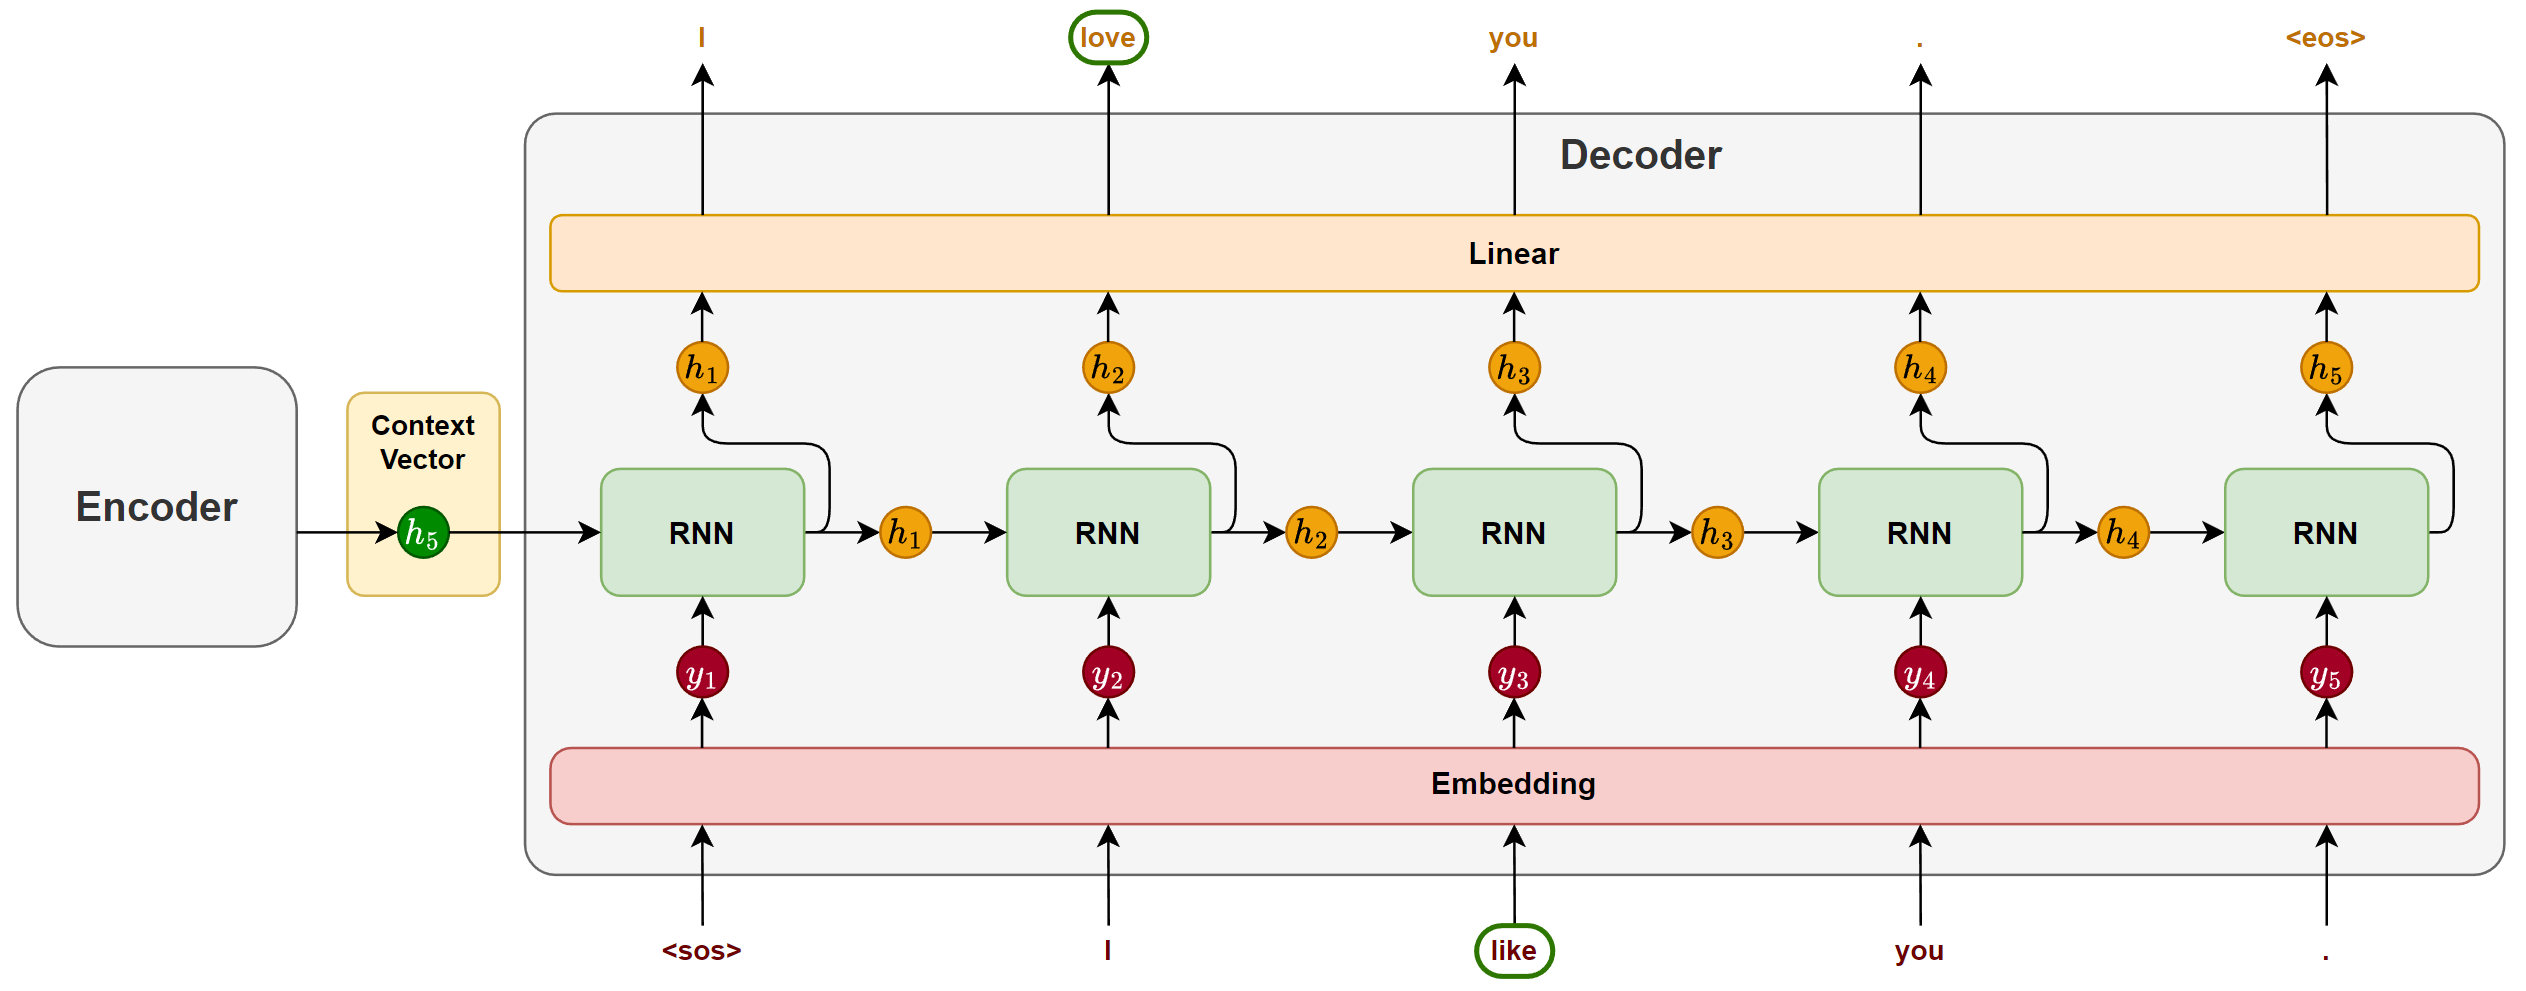

### 问题：训练初期解码器的输入是「错的」

推理时，解码器的下一步输入是**自己上一步的预测**。但训练初期模型乱猜，预测错误，导致：
- 错误输入 → 更多错误 → 梯度信号极差 → 收敛极慢

### Teacher Forcing 的解法

**训练时**：不管模型预测对不对，下一步输入强制用**真实的目标序列**（Ground Truth）：

```
目标序列：[SOS, 5, 3, 1, 4, EOS]

不用 Teacher Forcing（推理方式）：
  步骤1: 输入SOS  -> 预测2(错) -> 步骤2输入2(错的)
  步骤2: 输入2    -> 预测7(错) -> 步骤3输入7(错的) ...

用 Teacher Forcing（训练方式）：
  步骤1: 输入SOS  -> 预测2(错) -> 步骤2输入5(GT, 正确的)
  步骤2: 输入5    -> 预测3(对) -> 步骤3输入3(GT, 正确的) ...
```

### Teacher Forcing Ratio

不总是使用 Teacher Forcing，用概率控制：

```python
if random.random() < teacher_forcing_ratio:
    next_input = ground_truth_token   # 使用真实标签
else:
    next_input = predicted_token      # 使用模型预测
```

- `ratio=1.0`：全程用真实标签，收敛最快，但推理和训练差距大
- `ratio=0.0`：全程自己预测，和推理一致，但收敛慢
- `ratio=0.5`：常用折中方案

> **曝光偏差（Exposure Bias）**：训练时用 GT，推理时用预测，两种分布不一致，
> 导致推理时误差积累。这是 Teacher Forcing 的副作用，Transformer 部分解决了此问题。

## 5. 特殊 Token：SOS / EOS / PAD

Seq2Seq 需要三种特殊标记：

| Token | 索引 | 全称 | 作用 |
|-------|------|------|------|
| PAD | 0 | Padding | 将不同长度序列填充到相同长度 |
| SOS | 1 | Start of Sequence | 解码器的第一个输入，告诉它「开始生成」|
| EOS | 2 | End of Sequence | 解码器输出，告诉它「停止生成」|

本任务中，数字 0-9 映射为索引 3-12：

```python
PAD, SOS, EOS = 0, 1, 2
VOCAB_SIZE = 13  # PAD/SOS/EOS + 数字0-9（索引3-12）
```

**目标序列格式**：

```
src（输入）: [3,  7,  2,  9,  5]         -- 长度5，直接是数字索引
tgt（目标）: [1,  5,  9,  2,  7,  3,  2] -- SOS + 反转后数字 + EOS，长度7
              SOS d5 d4  d3  d2  d1  EOS
```

**解码器使用方式**：

```
输入 tgt[0]=SOS  ->  预测 tgt[1]=5
输入 tgt[1]=5    ->  预测 tgt[2]=9
...
输入 tgt[5]=3    ->  预测 tgt[6]=EOS
```

## 6. 训练 vs 推理流程对比

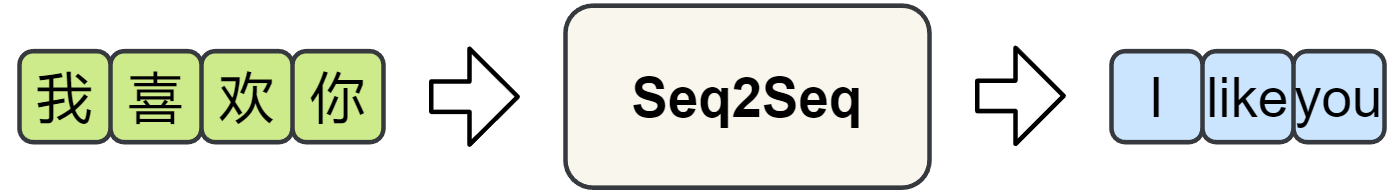

```
训练（Teacher Forcing）：
  src  ->  Encoder  ->  hidden
  t=1: input=SOS(GT)    ->  Decoder  ->  logit1  (loss vs tgt[1])
  t=2: input=tgt[1](GT) ->  Decoder  ->  logit2  (loss vs tgt[2])
  t=3: input=tgt[2](GT) ->  Decoder  ->  logit3  (loss vs tgt[3])
  ...
  所有 logit 一起计算 CrossEntropyLoss，反向传播

推理（自回归）：
  src  ->  Encoder  ->  hidden
  t=1: input=SOS        ->  Decoder  ->  logit1  ->  pred1=argmax(logit1)
  t=2: input=pred1      ->  Decoder  ->  logit2  ->  pred2=argmax(logit2)
  t=3: input=pred2      ->  Decoder  ->  logit3  ->  pred3=argmax(logit3)
  ...直到 pred=EOS 或达到最大长度
```

**关键区别**：下一步的输入来源不同
- 训练：来自真实标签（Ground Truth）
- 推理：来自模型自身的预测

## 7. 完整代码：数字反转任务

**任务**：输入一串数字，输出它的逆序。

```
[3, 7, 2, 9, 5]  ->  [5, 9, 2, 7, 3]
[1, 4, 1, 5, 9]  ->  [9, 5, 1, 4, 1]
```

**选择这个任务的原因**：
- 有明确的正确答案，准确率易于衡量
- 不需要语言知识，纯粹测试 Seq2Seq 架构
- 模型需要真正「记住」整个输入，才能正确反转

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# ===== 常量 =====
PAD, SOS, EOS = 0, 1, 2
VOCAB_SIZE = 13   # PAD/SOS/EOS(0-2) + 数字0-9(3-12)
EMBED_DIM  = 16
HIDDEN_DIM = 64
BATCH_SIZE = 64
SEQ_LEN    = 5

print(f'PAD={PAD}, SOS={SOS}, EOS={EOS}')
print(f'数字 0->索引 3, 数字 9->索引 12')

In [ ]:
# ===== Encoder =====
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x: (batch, src_len)
        embedded = self.embedding(x)          # (batch, src_len, embed_dim)
        _, hidden = self.gru(embedded)        # hidden: (1, batch, hidden_dim)
        return hidden                         # Context Vector


# ===== Decoder =====
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x:      (batch, 1)             -- 每次只输入一个 token
        # hidden: (1, batch, hidden_dim) -- 上一步的隐藏状态
        embedded = self.embedding(x)                    # (batch, 1, embed_dim)
        output, hidden = self.gru(embedded, hidden)     # output: (batch, 1, hidden_dim)
        logits = self.fc(output.squeeze(1))             # (batch, vocab_size)
        return logits, hidden


# ===== 验证 shape =====
enc = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
dec = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)

src_test = torch.randint(3, 13, (4, SEQ_LEN))          # batch=4
ctx = enc(src_test)
print('Encoder context shape:', ctx.shape)              # (1, 4, 64)

tok = torch.full((4, 1), SOS, dtype=torch.long)
logits, h = dec(tok, ctx)
print('Decoder logits shape: ', logits.shape)           # (4, 13)
print('Decoder hidden shape: ', h.shape)                # (1, 4, 64)

In [ ]:
# ===== Seq2Seq =====
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src: (batch, src_len)
        # tgt: (batch, tgt_len)  格式: [SOS, d1, d2, ..., EOS]
        batch_size = src.size(0)
        tgt_len    = tgt.size(1)
        vocab_size = self.decoder.fc.out_features

        # 1. Encoder 压缩输入
        hidden = self.encoder(src)   # (1, batch, hidden_dim)

        # 2. 存储每步输出
        outputs = torch.zeros(batch_size, tgt_len, vocab_size)

        # 3. 解码：第一个输入是 SOS
        input_token = tgt[:, 0:1]    # (batch, 1) = SOS

        for t in range(1, tgt_len):
            logits, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = logits

            # Teacher Forcing：随机决定下一步用 GT 还是预测
            if random.random() < teacher_forcing_ratio:
                input_token = tgt[:, t:t+1]            # Ground Truth
            else:
                input_token = logits.argmax(1, keepdim=True)  # 模型预测

        return outputs   # (batch, tgt_len, vocab_size)


encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
model   = Seq2Seq(encoder, decoder)

total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {total_params:,}')

In [ ]:
# ===== 数据生成 =====
def make_batch(batch_size, seq_len=SEQ_LEN):
    # 随机生成数字序列（0-9 映射到索引 3-12）
    src = torch.randint(3, 13, (batch_size, seq_len))   # (batch, seq_len)

    # 目标：反转后的序列，加 SOS 和 EOS
    # tgt 格式：[SOS, d_last, ..., d_first, EOS]，长度 = seq_len + 2
    tgt = torch.zeros(batch_size, seq_len + 2, dtype=torch.long)
    tgt[:, 0] = SOS
    for i in range(seq_len):
        tgt[:, i + 1] = src[:, seq_len - 1 - i]   # 反转
    tgt[:, seq_len + 1] = EOS

    return src, tgt


# 验证
src_ex, tgt_ex = make_batch(2)
print('src:', src_ex[0].tolist())
print('tgt:', tgt_ex[0].tolist(), '(SOS + 反转 + EOS)')

## 7.5 训练前的关键概念：梯度爆炸 / 梯度消失 / 梯度裁剪

> 上面的训练代码里有一行 `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)`，这是干嘛的？为什么 RNN/GRU/Seq2Seq 的训练几乎都会用？这一节回答这两个问题。

### 一、问题根源：BPTT 中的梯度连乘

训练 RNN 时使用 **BPTT（Backpropagation Through Time，沿时间反向传播）**：梯度沿时间步**链式传递回去**。下图为 RNN 的训练计算图：

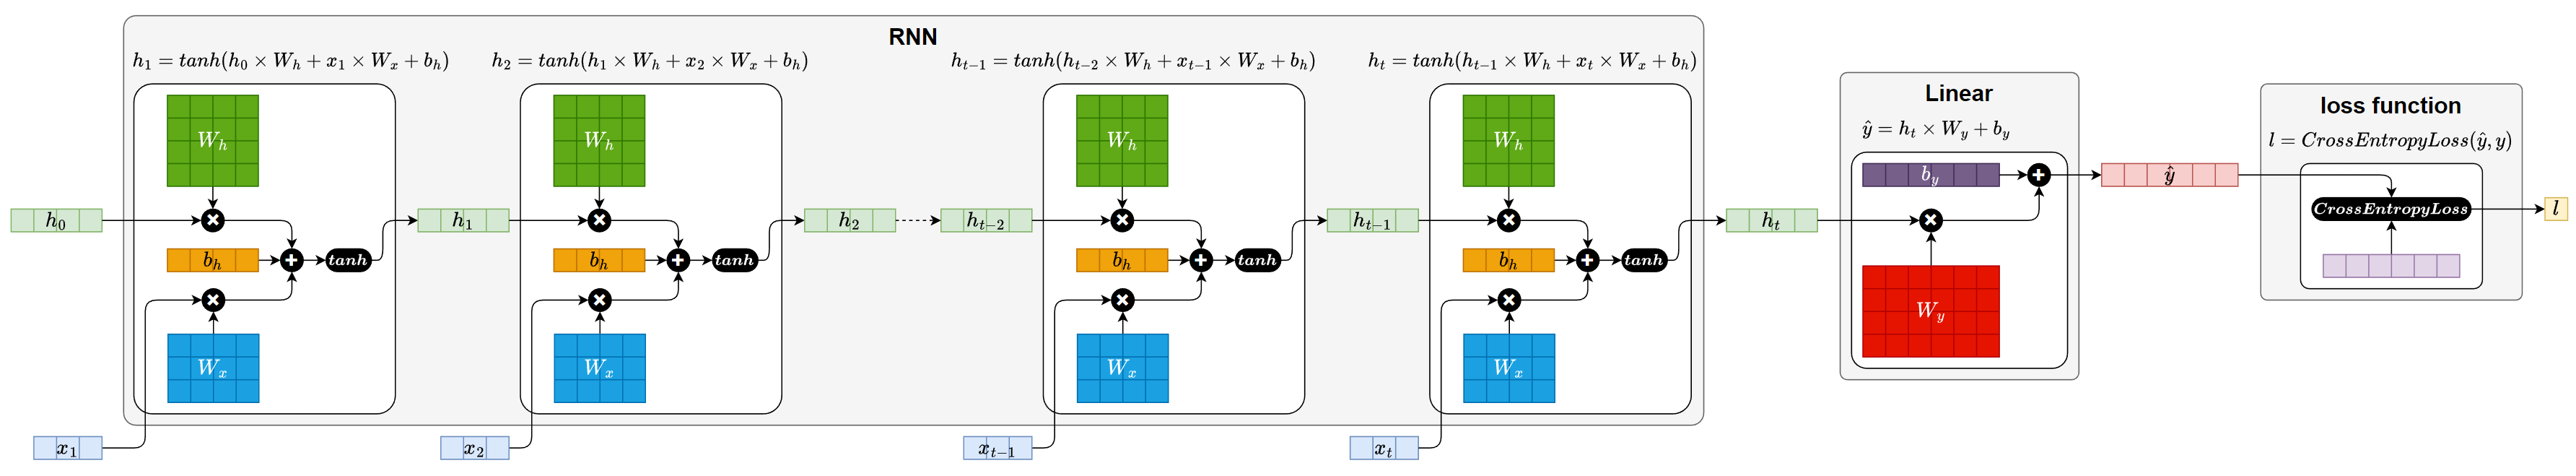

$$ u_t = W_h h_{t-1} + W_x x_t + b $$

$$ h_t = \tanh(u_t) $$

由于 $W_h$ 在每个时间步都被复用，按链式法则展开（以 $W_h$ 为例）：

$$
\frac{\partial L}{\partial W_h} = \sum_{k=1}^{T} \frac{\partial L}{\partial h_k} \cdot \frac{\partial h_k}{\partial W_h}
$$

其中 $\frac{\partial L}{\partial h_k}$ 需要从最后一步沿时间反向传回 $h_k$，越早的时间步（$k$ 越小），连乘项越多：

$$
\frac{\partial L}{\partial h_k} = \frac{\partial L}{\partial h_T}\cdot\prod_{t=k+1}^{T}\frac{\partial h_t}{\partial h_{t-1}}
$$

> 符号说明：$\sum$ 是连加，$\prod$（大写 Pi）是连乘。$\prod_{t=k+1}^{T}$ 表示 $t$ 从 $k+1$ 走到 $T$，每一项相乘。

代入 $\frac{\partial h_t}{\partial h_{t-1}} = \tanh'(u_t)\cdot W_h$（其中 $u_t = W_h h_{t-1} + W_x x_t + b$）：

$$
\frac{\partial L}{\partial h_k} = \frac{\partial L}{\partial h_T}\cdot\left(\prod_{t=k+1}^{T}\tanh'(u_t)\right)\cdot W_h^{\,T-k}
$$

**关键观察**：$W_h$ 自乘了 $T-k$ 次。最早的时间步（$k=1$）会出现 $W_h^{T-1}$——**T 越大，连乘越深**，这就是梯度爆炸 / 消失的根源。

**T=4 时的具体形态**（最早的 $k=1$ 路径）：

$$
\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_4}\cdot\tanh'(u_4)\cdot\tanh'(u_3)\cdot\tanh'(u_2)\cdot W_h^{3}
$$

### 二、tanh 导数 ∈ (0, 1]，但 W 才是关键

tanh 导数图像：

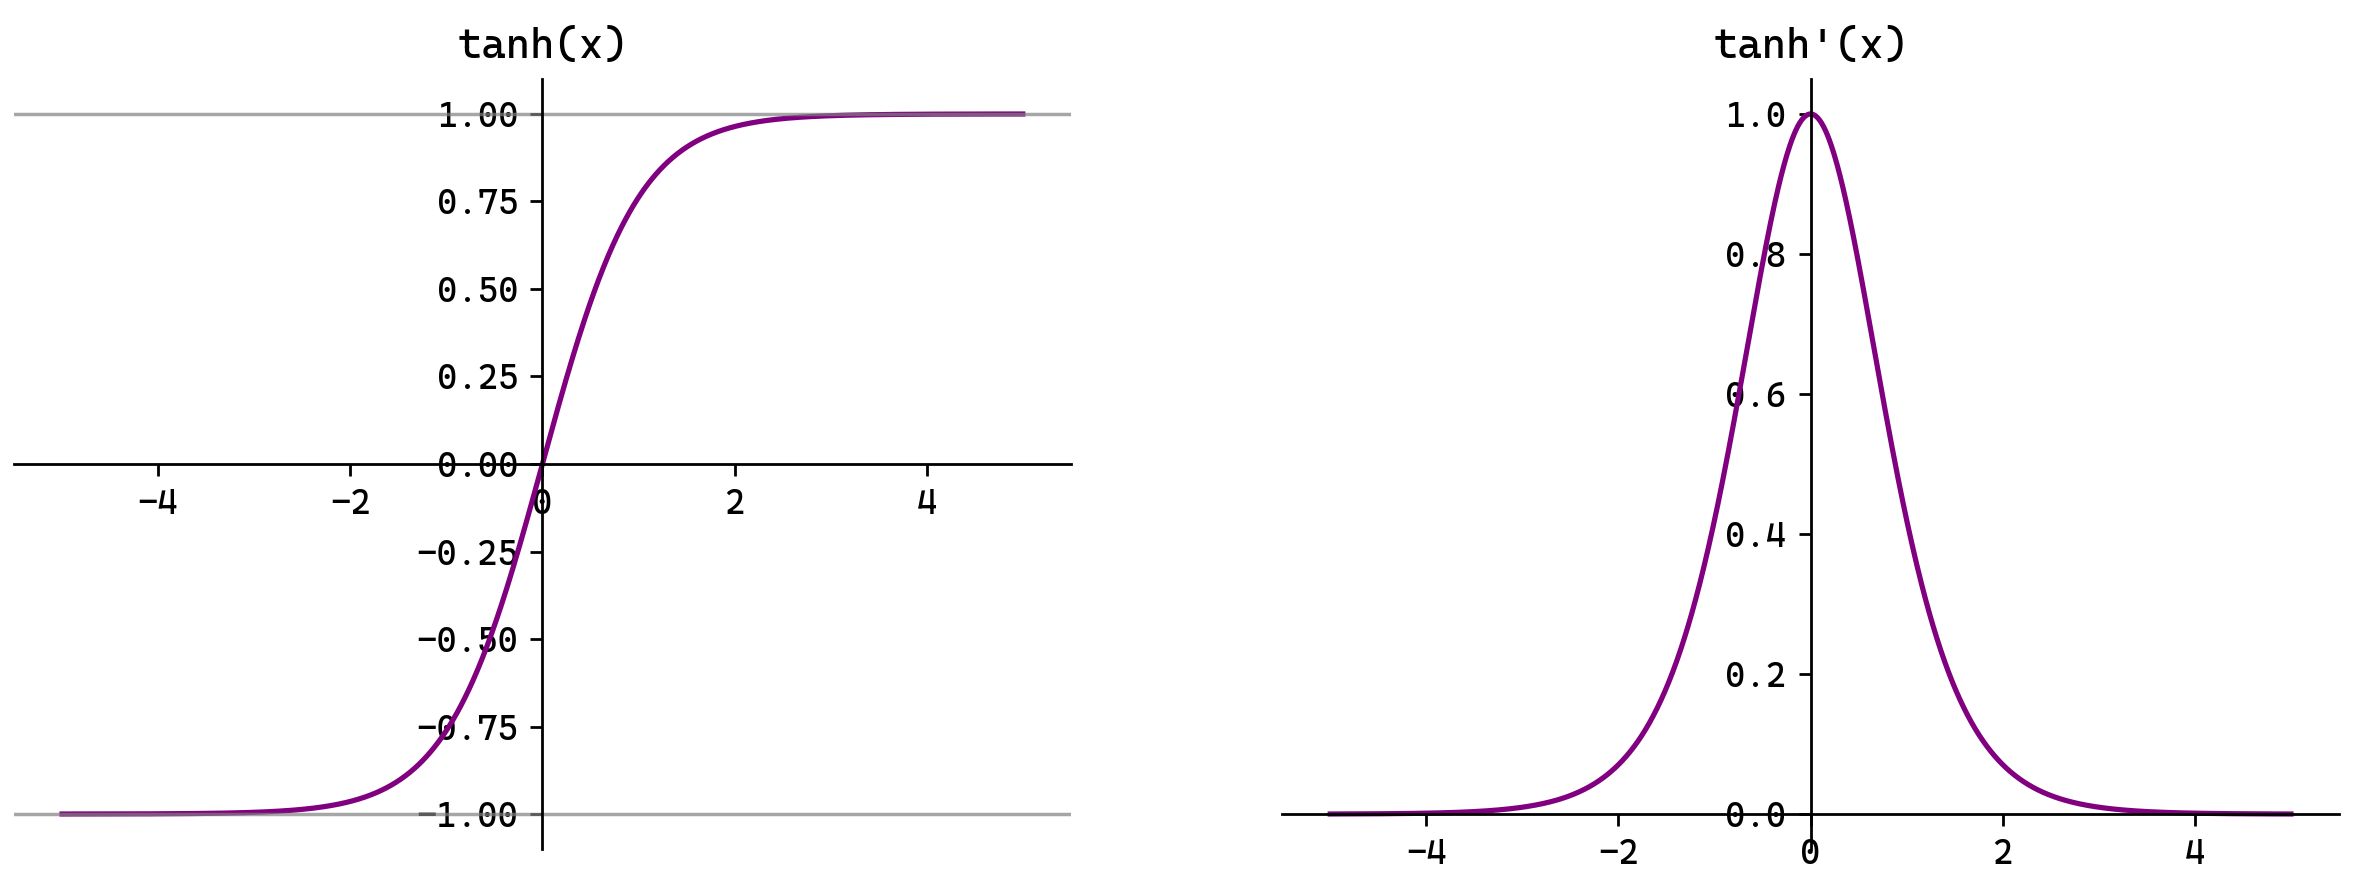

可以看到 $\tanh'(u) \in (0, 1]$，**永远不会放大**。所以衰减 / 放大与否，取决于 $W_h$：

| 情况 | 结果 |
|------|------|
| $|W_h| < 1$ | 连乘 → 指数衰减到 0，**梯度消失** |
| $|W_h| > 1$ | 连乘 → 指数增长到 ∞，**梯度爆炸** |

> 多维情况下，"$|W_h|$" 严格地说是 W 的**谱半径**（最大特征值的绝对值），但直觉一致：**矩阵的"放大倍数" > 1 → 爆炸；< 1 → 消失**。

### 三、两种现象的影响

- **梯度消失**：早期时间步的梯度近乎为 0 → 模型学不到长距离依赖（"长期依赖"建模困难）
- **梯度爆炸**：梯度变成天文数字 → 参数更新一步就崩，loss 直接 `NaN`

---

### 四、解决方案

| 问题 | 解决思路 |
|------|---------|
| 梯度消失 | **架构层面**：GRU/LSTM 的门控 + 线性插值，提供"梯度高速公路" |
| 梯度爆炸 | **工程层面**：**梯度裁剪（Gradient Clipping）** |

GRU 解决了消失（U07 已学），但**不能解决爆炸**——这就是为什么训练时还需要 `clip_grad_norm_`。

---

### 五、梯度裁剪：`clip_grad_norm_`

**思想**：给梯度的"总长度"设一个上限，超过就**按比例缩短，方向不变**：

$$
g \leftarrow g \cdot \min\left(1,\; \frac{\text{max\_norm}}{\|g\|}\right)
$$

```python
loss.backward()                                                    # 1. 算梯度
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # 2. 裁剪
optimizer.step()                                                   # 3. 更新参数
```

**调用位置**：必须在 `backward()` 之后、`step()` 之前。

**`max_norm` 怎么选**：经验值，常用 `1.0` 或 `5.0`。训练 NaN 频发就调小，几乎从不触发可以放大或省略。

**函数末尾的 `_`**：PyTorch 约定 = 原地修改梯度，无需接收返回值。

---

### 六、一句话记忆

> **GRU 防消失（架构），梯度裁剪防爆炸（训练技巧），两者搭配使用，是 RNN/Seq2Seq 训练的标配组合。**


In [ ]:
# ===== 训练 =====
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss(ignore_index=PAD)

def train_epoch(n_batches=200, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0
    for _ in range(n_batches):
        src, tgt = make_batch(BATCH_SIZE)
        optimizer.zero_grad()

        outputs = model(src, tgt, teacher_forcing_ratio)
        # outputs: (batch, tgt_len, vocab_size)
        # 跳过 t=0（SOS 位置不需要预测）
        # outputs[:,1:,:] 对应预测 tgt[:,1:]（即 d1..EOS）
        loss = loss_fn(
            outputs[:, 1:, :].reshape(-1, VOCAB_SIZE),
            tgt[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
        optimizer.step()
        total_loss += loss.item()

    return total_loss / n_batches


# ===== 推理 =====
def predict(src):
    model.eval()
    with torch.no_grad():
        hidden = model.encoder(src)
        input_token = torch.full((src.size(0), 1), SOS, dtype=torch.long)
        preds = []
        for _ in range(SEQ_LEN + 2):   # 最多生成 seq_len+2 步
            logits, hidden = model.decoder(input_token, hidden)
            pred = logits.argmax(1, keepdim=True)   # (batch, 1)
            preds.append(pred)
            input_token = pred
    return torch.cat(preds, dim=1)   # (batch, max_len)


# ===== 准确率（完全匹配）=====
def accuracy(n_batches=50):
    correct, total = 0, 0
    for _ in range(n_batches):
        src, tgt = make_batch(BATCH_SIZE)
        preds = predict(src)              # (batch, max_len)
        pred_seq = preds[:, :SEQ_LEN]     # 取前 SEQ_LEN 个预测
        true_seq = tgt[:, 1:SEQ_LEN+1]   # 跳过 SOS，取 SEQ_LEN 个真实值
        correct += (pred_seq == true_seq).all(dim=1).sum().item()
        total   += src.size(0)
    return correct / total


# ===== 训练主循环 =====
print('开始训练...')
for epoch in range(1, 11):
    loss = train_epoch()
    acc  = accuracy()
    print(f'Epoch {epoch:2d} | loss={loss:.4f} | val_acc={acc:.1%}')
    if acc > 0.95:
        print('通关！准确率 >95%')
        break

In [ ]:
# ===== 效果演示 =====
model.eval()
src_demo, _ = make_batch(5)
preds = predict(src_demo)

print('输入 -> 预测 (期望)')
for i in range(5):
    src_digits  = [x - 3 for x in src_demo[i].tolist()]               # 转回 0-9
    pred_digits = [x - 3 for x in preds[i, :SEQ_LEN].tolist()]        # 取前5个
    expected    = src_digits[::-1]
    ok = '✓' if pred_digits == expected else '✗'
    print(f'  {src_digits} -> {pred_digits}  (期望 {expected}) {ok}')

## 8. 本单元小结

| 概念 | 一句话 |
|------|--------|
| Seq2Seq | 解耦输入输出长度：Encoder 压缩理解，Decoder 逐步生成 |
| Context Vector | Encoder 最后时刻的 hidden state，是唯一的信息通道 |
| Encoder | 普通 GRU，只保留最后 hidden，shape=(1, batch, hidden) |
| Decoder | 每步处理一个 token，初始 hidden=context vector |
| Teacher Forcing | 训练时用 GT 作为下一步输入，加速收敛 |
| 曝光偏差 | 训练用 GT，推理用预测，分布不一致，误差会积累 |
| SOS/EOS/PAD | 控制解码开始/结束/填充的特殊标记 |

**Seq2Seq 数据流总结**：
```
src (batch, L_in)
  -> Embedding -> (batch, L_in, embed)
  -> GRU       -> hidden (1, batch, hidden)       [Encoder]
  -> Decoder 循环:
       每步: token (batch,1) + hidden -> logits (batch, vocab) + new_hidden
       直到 EOS 或最大长度                         [Decoder]
```

下一单元：**U09 中文数据处理** —— 构建真实的中英翻译数据集，处理分词、词典、变长序列。